# Rice Classification

### Introduction
##### Rice is one of the most widely consumed staple foods worldwide, and its quality control plays a crucial role in agriculture and food production. Automated classification of rice grains can help in distinguishing different rice varieties, ensuring consistency in production, and improving quality assessment. In this project, we aim to build a deep learning-based image classification model using Convolutional Neural Networks (CNN) to classify different types of rice grains.

#### Dataset
##### The dataset used in this project is the Rice Image Dataset, available on Kaggle. It consists of images of five different types of rice:

##### Arborio
##### Basmati
##### Ipsala
##### Jasmine
##### Karacadag
##### Each rice type has multiple high-resolution images captured under controlled conditions. The dataset provides a well-structured basis for training machine learning and deep learning models for rice classification.

#### Objective
##### The goal of this project is to:

##### Preprocess the rice images to ensure uniformity in size and format.
##### Train a CNN model to learn distinguishing features of different rice types.
##### Evaluate model performance using metrics such as accuracy, precision, and recall.
##### Optimize the model using techniques like data augmentation, transfer learning, or hyperparameter tuning to improve classification accuracy.

In [ ]:
import cv2
import pandas as pd
import os
import numpy as np
# Removed unused import: from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Define rice classes and dataset path
labels = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
img_path = 'Rice_Image_Dataset/'

In [5]:
os.listdir('Rice_Image_Dataset')

['Arborio',
 'Basmati',
 'Ipsala',
 'Jasmine',
 'Karacadag',
 'Rice_Citation_Request.txt']

In [6]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+'/'+img_file)
        label_list.append(label)

In [ ]:
# Create a DataFrame with image paths and labels
df = pd.DataFrame({'img': img_list, 'label': label_list})

In [8]:
df.head()

,img,label
0,Rice_Image_Dataset/Arborio/Arborio (1).jpg,Arborio
1,Rice_Image_Dataset/Arborio/Arborio (10).jpg,Arborio
2,Rice_Image_Dataset/Arborio/Arborio (100).jpg,Arborio
3,Rice_Image_Dataset/Arborio/Arborio (1000).jpg,Arborio
4,Rice_Image_Dataset/Arborio/Arborio (10000).jpg,Arborio


In [9]:
df.tail()

,img,label
74995,Rice_Image_Dataset/Karacadag/Karacadag (9995).jpg,Karacadag
74996,Rice_Image_Dataset/Karacadag/Karacadag (9996).jpg,Karacadag
74997,Rice_Image_Dataset/Karacadag/Karacadag (9997).jpg,Karacadag
74998,Rice_Image_Dataset/Karacadag/Karacadag (9998).jpg,Karacadag
74999,Rice_Image_Dataset/Karacadag/Karacadag (9999).jpg,Karacadag


In [10]:
df.shape

(75000, 2)

In [ ]:
# Encode labels to numerical values
d = {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}
df['encode_label'] = df['label'].map(d)

In [ ]:
# Load and preprocess images
x = []
for img_path in df['img']:  # Use img_path to avoid shadowing
    image = cv2.imread(img_path)  # Read the image
    if image is not None:
        image = cv2.resize(image, (64, 64))  # Resize the image to 64x64
        processed_img = image / 255.0  # Normalize the image to [0, 1]
        x.append(processed_img)  # Append the processed image to the list
    else:
        print(f"Failed to read image: {img_path}")

In [13]:
y=df['encode_label']

In [14]:
x=np.array(x)

In [19]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [ ]:
# Data augmentation to improve model generalization
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(x_train)

In [22]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 64, 64, 3)
(60000,)
(15000, 64, 64, 3)
(15000,)


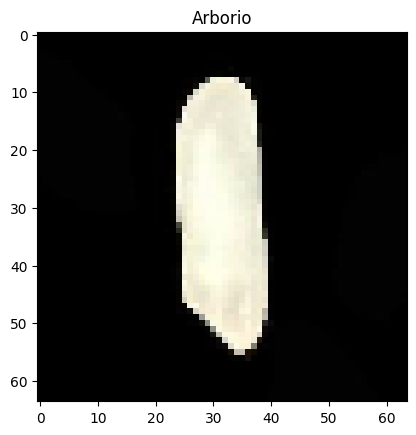

In [23]:
plt.imshow(x_train[2000])
plt.title(labels[int(y_train[2000])]);

In [24]:
from keras.models import Sequential
from keras.layers import Conv2D, Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape

### CNN 

In [ ]:
# Build the CNN model
model = Sequential()
model.add(Input(shape=(64, 64, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Added activation function
model.add(Dense(len(labels), activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model with data augmentation
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.9318 - loss: 0.1959 - val_accuracy: 0.9887 - val_loss: 0.0390
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9856 - loss: 0.0430 - val_accuracy: 0.9905 - val_loss: 0.0315
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 49ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9913 - val_loss: 0.0281
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9924 - loss: 0.0230 - val_accuracy: 0.9941 - val_loss: 0.0190
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9919 - val_loss: 0.0244
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9954 - loss: 0.0141 - val_accuracy: 0.9910 - val_loss: 0.0291
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9969 - loss: 0.0101 - val_accuracy: 0.9962 - val_loss: 0.0145
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9965 -

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
# Save the trained model
model.save('my_rice_cnn_model.h5')

### Conclusion
##### In this project, we successfully developed a deep learning-based model for classifying different types of rice using the Rice Image Dataset. By leveraging Convolutional Neural Networks (CNNs), we were able to extract meaningful features from rice grain images and achieve a high classification accuracy.